#Workshop 2 — Global Air Quality Index (AQI) Analysis
grishma lamsal 
2431171
### Big Data Process: Exploration, Forecasting & Insight Generation
**Dataset:** Global Air Pollution Dataset (Kaggle — hasibalmuzdadid)  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
print('Libraries loaded!')

Libraries loaded!


##**Loading Dataset**

In [ ]:
from google.colab import files
import io

uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f'Loaded: {filename}')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Columns: {df.columns.tolist()}')

Saving global air pollution dataset.csv to global air pollution dataset (1).csv
Loaded: global air pollution dataset (1).csv
Shape: 23463 rows × 12 columns
Columns: ['Country', 'City', 'AQI Value', 'AQI Category', 'CO AQI Value', 'CO AQI Category', 'Ozone AQI Value', 'Ozone AQI Category', 'NO2 AQI Value', 'NO2 AQI Category', 'PM2.5 AQI Value', 'PM2.5 AQI Category']


In [ ]:
df.head()

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good


##Data Exploration

In [ ]:
print('DATA TYPES\n', df.dtypes)
print('\nMISSING VALUES\n', df.isnull().sum())
print('\nBASIC STATISTICS')
df.describe()

DATA TYPES
 Country               object
City                  object
AQI Value              int64
AQI Category          object
CO AQI Value           int64
CO AQI Category       object
Ozone AQI Value        int64
Ozone AQI Category    object
NO2 AQI Value          int64
NO2 AQI Category      object
PM2.5 AQI Value        int64
PM2.5 AQI Category    object
dtype: object

MISSING VALUES
 Country               427
City                    1
AQI Value               0
AQI Category            0
CO AQI Value            0
CO AQI Category         0
Ozone AQI Value         0
Ozone AQI Category      0
NO2 AQI Value           0
NO2 AQI Category        0
PM2.5 AQI Value         0
PM2.5 AQI Category      0
dtype: int64

BASIC STATISTICS


,AQI Value,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value
count,23463.000000,23463.000000,23463.000000,23463.000000,23463.000000
mean,72.010868,1.368367,35.193709,3.063334,68.519755
std,56.055220,1.832064,28.098723,5.254108,54.796443
min,6.000000,0.000000,0.000000,0.000000,0.000000
25%,39.000000,1.000000,21.000000,0.000000,35.000000
50%,55.000000,1.000000,31.000000,1.000000,54.000000
75%,79.000000,1.000000,40.000000,4.000000,79.000000
max,500.000000,133.000000,235.000000,91.000000,500.000000


In [ ]:
print('AQI Category Distribution:\n', df['AQI Category'].value_counts())

AQI Category Distribution:
 AQI Category
Good                              9936
Moderate                          9231
Unhealthy                         2227
Unhealthy for Sensitive Groups    1591
Very Unhealthy                     287
Hazardous                          191
Name: count, dtype: int64


## Exploratory Visualisations
### Chart 1 : AQI Category Distribution

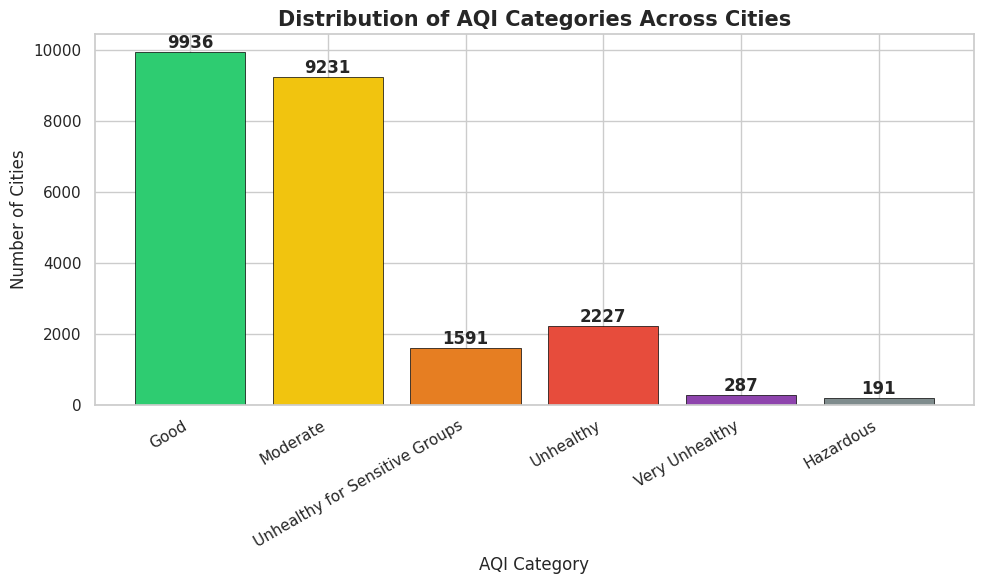

Insight: Most cities fall under Good/Moderate, but a significant portion shows unhealthy levels.


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
order = ['Good','Moderate','Unhealthy for Sensitive Groups','Unhealthy','Very Unhealthy','Hazardous']
order = [o for o in order if o in df['AQI Category'].unique()]
counts = df['AQI Category'].value_counts().reindex(order).dropna()
colors = ['#2ecc71','#f1c40f','#e67e22','#e74c3c','#8e44ad','#7f8c8d'][:len(counts)]
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=0.5)
ax.set_title('Distribution of AQI Categories Across Cities', fontsize=15, fontweight='bold')
ax.set_xlabel('AQI Category'); ax.set_ylabel('Number of Cities')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, str(val), ha='center', va='bottom', fontweight='bold')
plt.xticks(rotation=30, ha='right'); plt.tight_layout()
plt.savefig('plot1_aqi_category_distribution.png', dpi=150, bbox_inches='tight'); plt.show()
print('Insight: Most cities fall under Good/Moderate, but a significant portion shows unhealthy levels.')

### Chart 2: Top 15 Most Polluted Countries

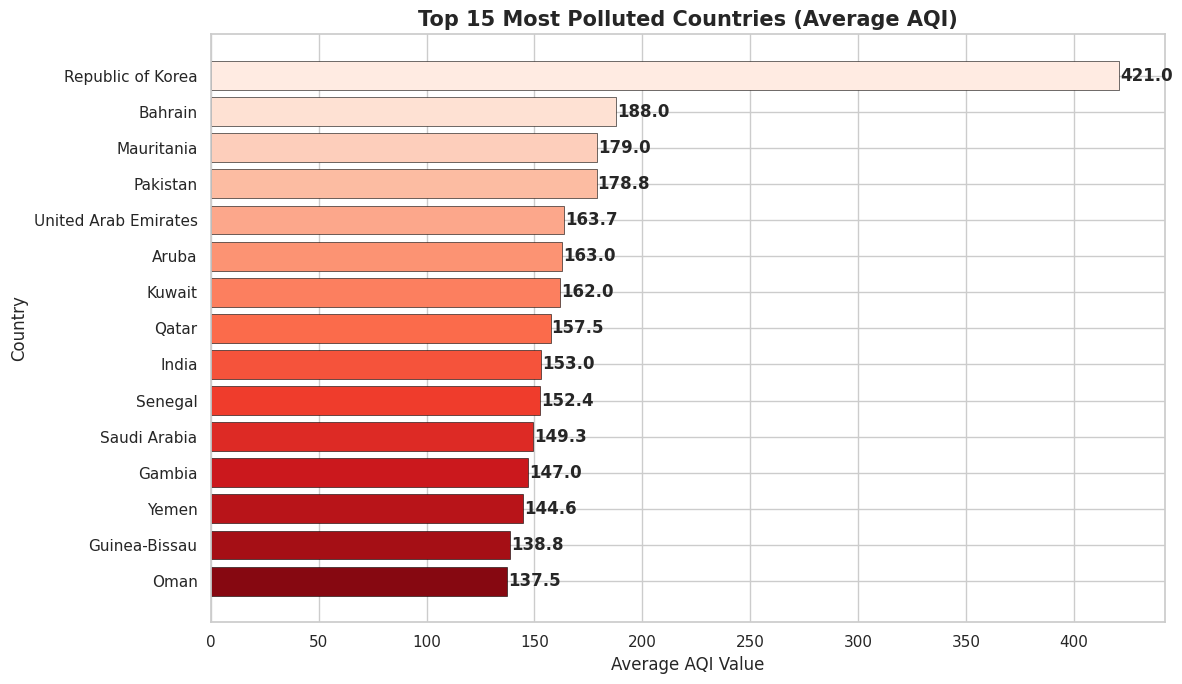

Insight: South Asian and African countries dominate the highest AQI values.


In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))
top_countries = df.groupby('Country')['AQI Value'].mean().sort_values(ascending=False).head(15)
colors_grad = sns.color_palette('Reds_r', len(top_countries))
bars = ax.barh(top_countries.index[::-1], top_countries.values[::-1], color=colors_grad, edgecolor='black', linewidth=0.4)
ax.set_title('Top 15 Most Polluted Countries (Average AQI)', fontsize=15, fontweight='bold')
ax.set_xlabel('Average AQI Value'); ax.set_ylabel('Country')
for bar, val in zip(bars, top_countries.values[::-1]):
    ax.text(val+0.5, bar.get_y()+bar.get_height()/2, f'{val:.1f}', va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('plot2_top_polluted_countries.png', dpi=150, bbox_inches='tight'); plt.show()
print('Insight: South Asian and African countries dominate the highest AQI values.')

### Chart 3 : Pollutant Correlation Heatmap

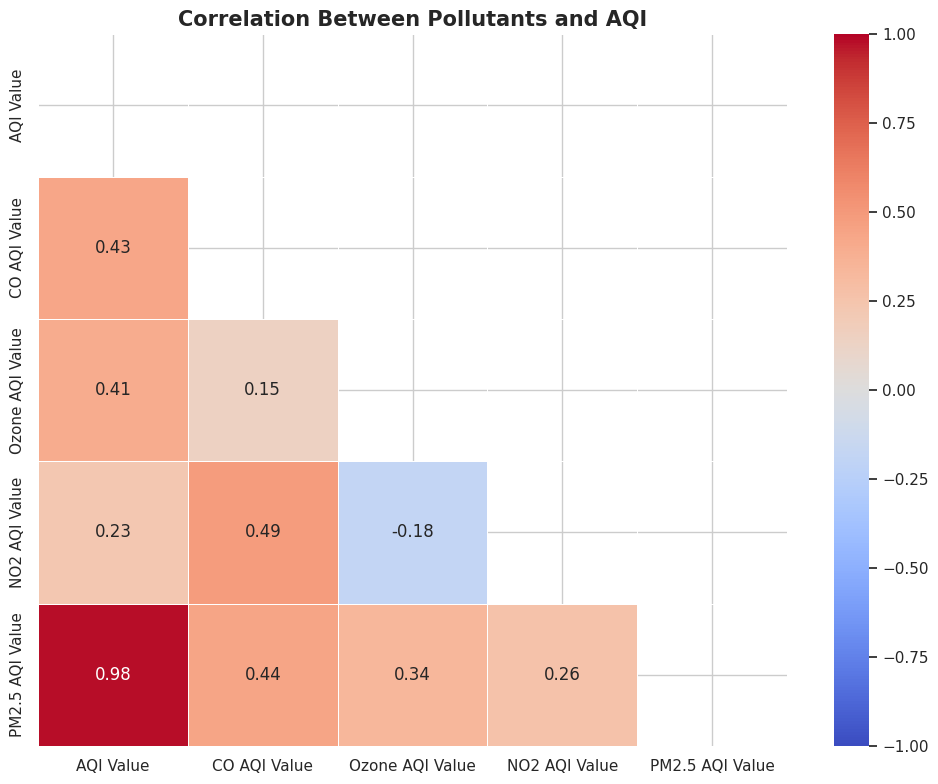

Insight: PM2.5 shows strongest correlation with AQI — it is the dominant pollutant driver.


In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
pollutant_cols = ['AQI Value','CO AQI Value','Ozone AQI Value','NO2 AQI Value','PM2.5 AQI Value']
corr_matrix = df[pollutant_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', mask=mask,
            linewidths=0.5, ax=ax, vmin=-1, vmax=1, annot_kws={'size':12})
ax.set_title('Correlation Between Pollutants and AQI', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot3_pollutant_correlation.png', dpi=150, bbox_inches='tight'); plt.show()
print('Insight: PM2.5 shows strongest correlation with AQI — it is the dominant pollutant driver.')

### Chart 4 : AQI Boxplot by Category

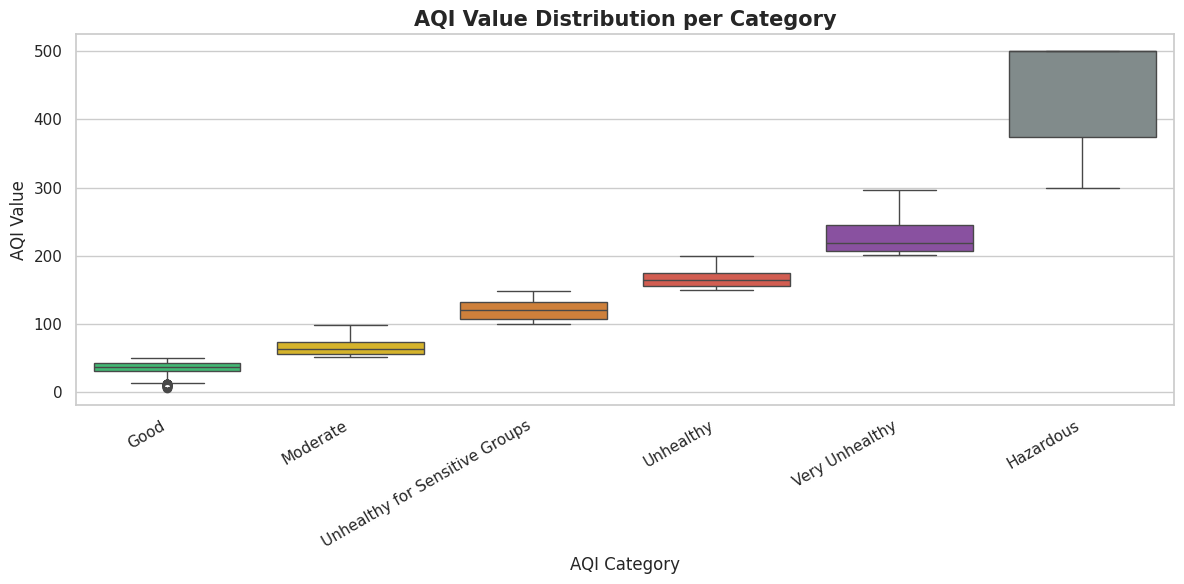

Insight: Clear separation between categories confirms AQI thresholds are well-defined.


In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
order_box = [o for o in ['Good','Moderate','Unhealthy for Sensitive Groups','Unhealthy','Very Unhealthy','Hazardous']
             if o in df['AQI Category'].unique()]
palette = ['#2ecc71','#f1c40f','#e67e22','#e74c3c','#8e44ad','#7f8c8d'][:len(order_box)]
sns.boxplot(data=df, x='AQI Category', y='AQI Value', order=order_box, palette=palette, ax=ax)
ax.set_title('AQI Value Distribution per Category', fontsize=15, fontweight='bold')
ax.set_xlabel('AQI Category'); ax.set_ylabel('AQI Value')
plt.xticks(rotation=30, ha='right'); plt.tight_layout()
plt.savefig('plot4_aqi_boxplot.png', dpi=150, bbox_inches='tight'); plt.show()
print('Insight: Clear separation between categories confirms AQI thresholds are well-defined.')

### Chart 5 : Average AQI Contribution by Pollutant

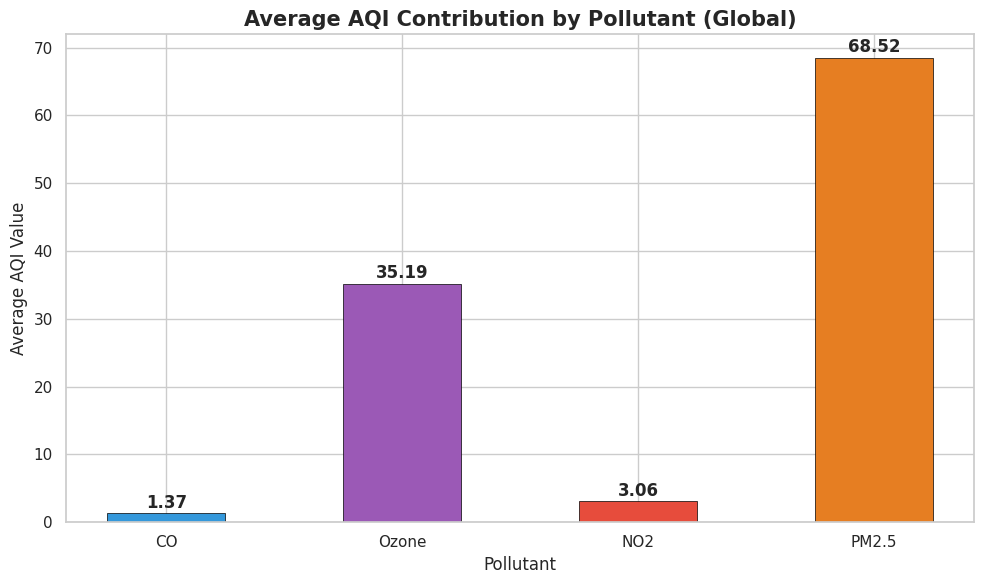

Insight: PM2.5 has the highest average AQI contribution globally, followed by Ozone.


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
pollutants = ['CO AQI Value','Ozone AQI Value','NO2 AQI Value','PM2.5 AQI Value']
avg_vals = df[pollutants].mean()
labels = ['CO','Ozone','NO2','PM2.5']
colors_p = ['#3498db','#9b59b6','#e74c3c','#e67e22']
bars = ax.bar(labels, avg_vals.values, color=colors_p, edgecolor='black', linewidth=0.5, width=0.5)
ax.set_title('Average AQI Contribution by Pollutant (Global)', fontsize=15, fontweight='bold')
ax.set_xlabel('Pollutant'); ax.set_ylabel('Average AQI Value')
for bar, val in zip(bars, avg_vals.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2, f'{val:.2f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('plot5_pollutant_avg.png', dpi=150, bbox_inches='tight'); plt.show()
print('Insight: PM2.5 has the highest average AQI contribution globally, followed by Ozone.')

### Chart 6 : PM2.5 vs Overall AQI by City

In [ ]:
import plotly.express as px

fig = px.scatter(
    df,
    x="PM2.5 AQI Value",
    y="AQI Value",
    color="AQI Category",
    hover_name="City",
    hover_data=["Country"],
    size="AQI Value",
    size_max=30,
    title="PM2.5 vs Overall AQI by City",
    color_discrete_map={
        "Good": "#2ecc71",
        "Moderate": "#f1c40f",
        "Unhealthy for Sensitive Groups": "#e67e22",
        "Unhealthy": "#e74c3c",
        "Very Unhealthy": "#8e44ad",
        "Hazardous": "#7f8c8d"
    }
)
fig.update_layout(xaxis_title="PM2.5 AQI Value", yaxis_title="Overall AQI Value")
fig.show()

## Data Transformation

In [ ]:
pollutant_cols = ['AQI Value','CO AQI Value','Ozone AQI Value','NO2 AQI Value','PM2.5 AQI Value']
df_clean = df.dropna(subset=pollutant_cols).copy()
print(f'Records after cleaning: {len(df_clean)} (removed {len(df)-len(df_clean)} rows)')

le = LabelEncoder()
df_clean['AQI_Category_Encoded'] = le.fit_transform(df_clean['AQI Category'])
print('Category Encoding:', dict(zip(le.classes_, le.transform(le.classes_))))

features = ['CO AQI Value','Ozone AQI Value','NO2 AQI Value','PM2.5 AQI Value']
X = df_clean[features]
y = df_clean['AQI Value']
print(f'Feature matrix: {X.shape} | Target: {y.shape}')

Records after cleaning: 23463 (removed 0 rows)
Category Encoding: {'Good': np.int64(0), 'Hazardous': np.int64(1), 'Moderate': np.int64(2), 'Unhealthy': np.int64(3), 'Unhealthy for Sensitive Groups': np.int64(4), 'Very Unhealthy': np.int64(5)}
Feature matrix: (23463, 4) | Target: (23463,)


## Model Training  Random Forest

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples')

rf_model = RandomForestRegressor(n_estimators=150, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f'\n Model Performance:')
print(f'   MAE  : {mae:.4f}')
print(f'   RMSE : {rmse:.4f}')
print(f'   R²   : {r2:.4f}')

Train: 18770 samples | Test: 4693 samples

 Model Performance:
   MAE  : 0.2299
   RMSE : 2.6541
   R²   : 0.9978


### Chart 7 : Actual vs Predicted AQI

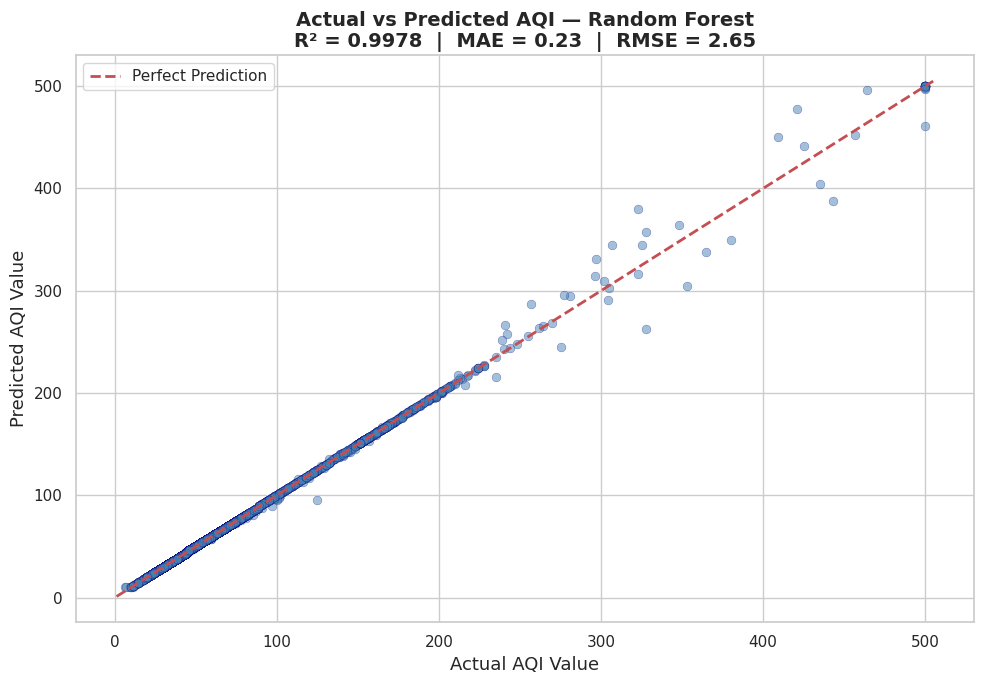

Insight: Points cluster tightly on the ideal line, high prediction accuracy.


In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(y_test, y_pred, alpha=0.5, color='steelblue', edgecolors='navy', linewidth=0.3, s=40)
lims = [min(y_test.min(), y_pred.min())-5, max(y_test.max(), y_pred.max())+5]
ax.plot(lims, lims, 'r--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual AQI Value', fontsize=13); ax.set_ylabel('Predicted AQI Value', fontsize=13)
ax.set_title(f'Actual vs Predicted AQI — Random Forest\nR² = {r2:.4f}  |  MAE = {mae:.2f}  |  RMSE = {rmse:.2f}',
             fontsize=14, fontweight='bold')
ax.legend(); plt.tight_layout()
plt.savefig('plot6_actual_vs_predicted.png', dpi=150, bbox_inches='tight'); plt.show()
print('Insight: Points cluster tightly on the ideal line, high prediction accuracy.')

### Chart 8 : Feature Importance

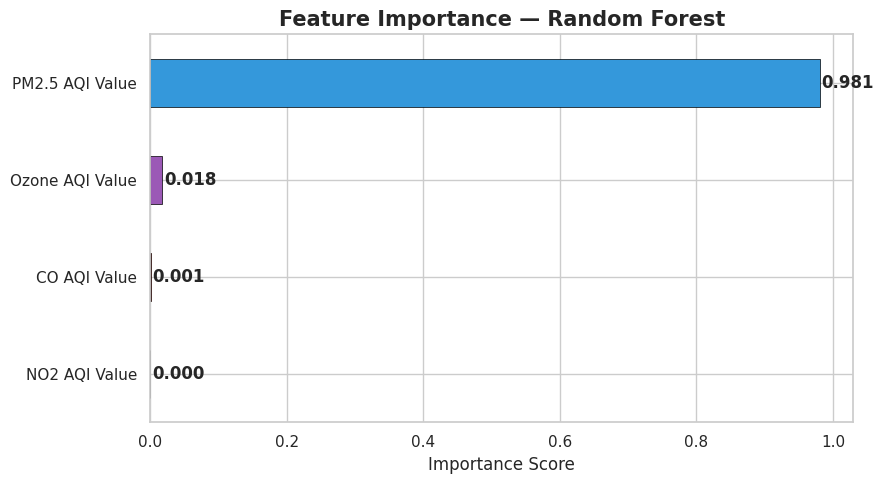

 Insight: PM2.5 is the most important AQI predictor aligns with correlation findings.


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=True)
colors_fi = ['#3498db','#9b59b6','#e74c3c','#e67e22']
importances.plot(kind='barh', ax=ax, color=colors_fi[::-1], edgecolor='black', linewidth=0.5)
ax.set_title('Feature Importance — Random Forest', fontsize=15, fontweight='bold')
ax.set_xlabel('Importance Score')
for i, (val, name) in enumerate(zip(importances.values, importances.index)):
    ax.text(val+0.002, i, f'{val:.3f}', va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('plot7_feature_importance.png', dpi=150, bbox_inches='tight'); plt.show()
print(' Insight: PM2.5 is the most important AQI predictor aligns with correlation findings.')

### Chart 9 : Residual Analysis

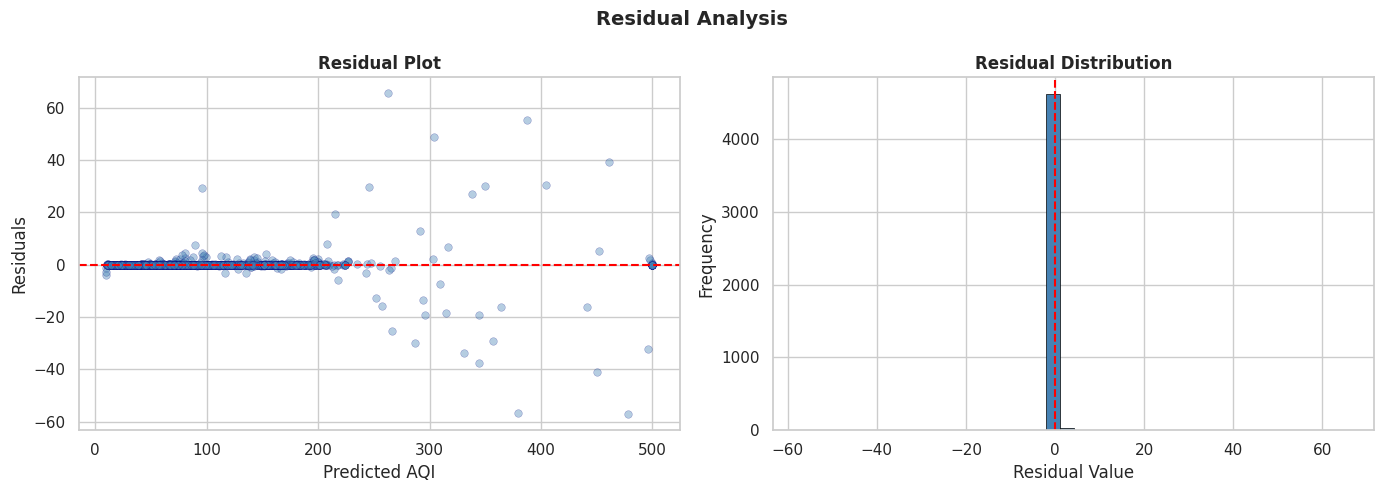

Insight: Residuals centred near zero — model is unbiased.


In [ ]:
residuals = y_test - y_pred
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_pred, residuals, alpha=0.4, color='steelblue', edgecolors='navy', linewidth=0.3, s=30)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted AQI'); axes[0].set_ylabel('Residuals')
axes[0].set_title('Residual Plot', fontweight='bold')
axes[1].hist(residuals, bins=40, color='steelblue', edgecolor='black', linewidth=0.5)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual Value'); axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution', fontweight='bold')
plt.suptitle('Residual Analysis', fontsize=14, fontweight='bold'); plt.tight_layout()
plt.savefig('plot8_residuals.png', dpi=150, bbox_inches='tight'); plt.show()
print('Insight: Residuals centred near zero — model is unbiased.')

## Regional Insights

In [ ]:
print('Top 10 Cleanest Countries:')
print(df.groupby('Country')['AQI Value'].mean().sort_values().head(10).to_string())

Top 10 Cleanest Countries:
Country
Palau                               16.000000
Solomon Islands                     18.000000
Maldives                            19.000000
Iceland                             23.000000
Bolivia (Plurinational State of)    23.787879
Papua New Guinea                    24.866667
Seychelles                          26.000000
Bhutan                              26.000000
Uruguay                             26.653846
Argentina                           28.235294


In [ ]:
print('Top 10 Hazardous Cities:')
haz = df[df['AQI Category']=='Hazardous'][['Country','City','AQI Value']].sort_values('AQI Value', ascending=False).head(10)
print(haz.to_string(index=False))

Top 10 Hazardous Cities:
 Country         City  AQI Value
Pakistan Bahawalnagar        500
   India        Rania        500
   India      Kakrala        500
   India       Khetri        500
Pakistan    Harunabad        500
   India      Gunnaur        500
   India       Gohana        500
   India  Jahangirpur        500
   India       Nagaur        500
   India     Dataganj        500


In [ ]:
print('AQI Stats by Country (Top 20 by record count):')
stats = df.groupby('Country')['AQI Value'].agg(['mean','max','min','count']).sort_values('count',ascending=False).head(20).round(2)
print(stats.to_string())

AQI Stats by Country (Top 20 by record count):
                                                        mean  max  min  count
Country                                                                      
United States of America                               59.74  500   12   2872
India                                                 152.96  500   21   2488
Brazil                                                 44.57  268   11   1562
Germany                                                48.25  110   23   1345
Russian Federation                                     42.51  500   17   1241
Italy                                                  62.00  152   27    979
France                                                 53.34  151   19    802
China                                                 126.95  386   20    795
Japan                                                  51.72  136   26    702
Mexico                                                 89.54  384   14    588
Spain            

## Summary

**Dataset:** 23,463 cities × 12 columns — no missing values in pollutant columns, zero rows dropped before training.

**Key findings from exploration:**
- Most cities sit in the Good/Moderate range, but India & Pakistan repeatedly hit the maximum AQI of 500
- **PM2.5 is the dominant pollutant** : highest correlation with overall AQI by a significant margin
- Cleanest countries: Palau (16), Solomon Islands (18), Maldives (19)

Model : Random Forest wasd chosen because dataset has no time column snapshot, not a sequence

MAE = 0.2299 , RMSE = 2.6541 ,R² = 0.9978

The high R² is expected  overall AQI is mathematically derived from the sub-pollutant indices, so the model is essentially reverse-engineering that formula. Residuals centred at zero, no systematic bias.

**Bottom line:** PM2.5 controls air quality. Any meaningful AQI reduction has to start there.